In [ ]:
# ==========================================
# STEP 1: INSTALASI & PERSIAPAN ENVIRONMENT
# ==========================================
!pip install transformers torch tqdm scikit-learn pandas

import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.svm import SVC
from google.colab import drive
import joblib

# Hubungkan ke Google Drive
drive.mount('/content/drive')

# Memuat data 26.999 baris yang sudah kita bersihkan di notebook sebelumnya
# PERHATIAN: Kita pakai kolom 'text' (asli), BUKAN 'clean_text' (Sastrawi)
path_data = "/content/drive/MyDrive/NLP_Project/df_train_master_cleaned.csv"
df = pd.read_csv(path_data)

# Pastikan tidak ada data kosong yang terselip
df = df.dropna(subset=['text', 'label'])
X_text = df['text'].astype(str).values
y_label = df['label'].values

print(f"Total data siap diproses: {len(X_text)} baris")

# ==========================================
# STEP 2: SETUP FINBERT & GPU ACCELERATION
# ==========================================
# Cek apakah GPU benar-benar aktif
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Mesin yang digunakan: {device}")

# Memanggil model FinBERT spesifik Bahasa Indonesia
model_name = "michaelmanurung/finbert-indonesia"
print(f"Mengunduh tokenizer dan model {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# ==========================================
# STEP 3: EKSTRAKSI FITUR (EMBEDDINGS)
# ==========================================
def extract_finbert_embeddings(texts, batch_size=32):
    all_embeddings = []

    # Kita proses per 32 kalimat sekaligus agar GPU tidak crash
    for i in tqdm(range(0, len(texts), batch_size), desc="Ekstraksi FinBERT"):
        batch = texts[i : i + batch_size].tolist()

        # Tokenisasi kalimat (Maksimal 128 kata per kalimat untuk efisiensi)
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Mengambil vektor token [CLS] (Token pertama) yang mewakili seluruh makna kalimat
            # Ukuran vektor: 1 kalimat = 768 angka unik
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

print("\nMemulai proses ekstraksi (Ini memakan waktu sekitar 5-10 menit)...")
X_embeddings = extract_finbert_embeddings(X_text)

print(f"Bentuk matriks fitur final: {X_embeddings.shape}")
# Harusnya tercetak: (26999, 768) -> 26.999 kalimat, masing-masing punya 768 angka fitur

# ==========================================
# STEP 4: PELATIHAN SVM BERBASIS FINBERT
# ==========================================
print("\nMelatih Support Vector Machine (SVM) menggunakan fitur FinBERT...")
# Kernel RBF seringkali lebih kuat untuk data kompleks dari Transformer dibandingkan kernel Linear
svm_finbert = SVC(kernel='rbf', C=1.0, random_state=42)
svm_finbert.fit(X_embeddings, y_label)

# Simpan Model dan Data Matriksnya
path_simpan = "/content/drive/MyDrive/NLP_Project/"
joblib.dump(svm_finbert, path_simpan + 'svm_finbert_model.pkl')

# Menyimpan matriks ekstraksi agar tidak perlu run Step 3 lagi ke depannya
np.save(path_simpan + 'X_finbert_embeddings.npy', X_embeddings)
np.save(path_simpan + 'y_labels.npy', y_label)

print("🎉 SELESAI! Model FinBERT+SVM berhasil dilatih dan disimpan ke Google Drive.")

Mounted at /content/drive
Total data siap diproses: 26999 baris
Mesin yang digunakan: cuda
Mengunduh tokenizer dan model michaelmanurung/finbert-indonesia...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/845 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michaelmanurung/finbert-indonesia
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Memulai proses ekstraksi (Ini memakan waktu sekitar 5-10 menit)...


Ekstraksi FinBERT: 100%|██████████| 844/844 [02:05<00:00,  6.74it/s]


Bentuk matriks fitur final: (26999, 768)

Melatih Support Vector Machine (SVM) menggunakan fitur FinBERT...
🎉 SELESAI! Model FinBERT+SVM berhasil dilatih dan disimpan ke Google Drive.


=== STEP 1: LOAD 4.997 DATA UJI ===
Data Uji siap: 4997 baris

=== STEP 2: SETUP FINBERT & GPU ===
Menggunakan: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/845 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: michaelmanurung/finbert-indonesia
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== STEP 3: EKSTRAKSI EMBEDDINGS (SOAL UJIAN) ===


Membaca Soal: 100%|██████████| 157/157 [30:53<00:00, 11.81s/it]



=== STEP 4: LOAD MODEL SVM-FINBERT & EVALUASI ===

✅ HASIL UJIAN FINBERT + SVM:
              precision    recall  f1-score   support

     Negatif       0.29      0.23      0.25      1261
      Netral       0.25      0.30      0.27      1360
     Positif       0.49      0.49      0.49      2376

    accuracy                           0.37      4997
   macro avg       0.34      0.34      0.34      4997
weighted avg       0.38      0.37      0.37      4997


=== VISUALISASI CONFUSION MATRIX ===


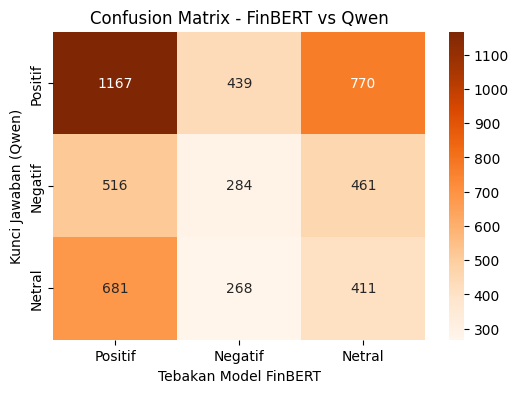

In [3]:
import pandas as pd
import torch
import numpy as np
import joblib
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=== STEP 1: LOAD 4.997 DATA UJI ===")
# Kita muat ulang 5 file ujiannya (sama seperti tadi)
file_names = ['INET_labeled.csv', 'DEWA_labeled.csv', 'AADI_labeled.csv', 'BUMI_labeled.csv', 'ELSA_labeled.csv']
path_folder = "/content/drive/MyDrive/NLP_qwen/"

list_df = []
for file in file_names:
    df_temp = pd.read_csv(path_folder + file)
    if 'content' in df_temp.columns and 'text' not in df_temp.columns:
        df_temp = df_temp.rename(columns={'content': 'text'})
    list_df.append(df_temp)

df_test = pd.concat(list_df, ignore_index=True).dropna(subset=['text', 'label'])
texts_test = df_test['text'].astype(str).values
y_test_asli = df_test['label'].values
print(f"Data Uji siap: {len(texts_test)} baris")

print("\n=== STEP 2: SETUP FINBERT & GPU ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan: {device}")

model_name = "michaelmanurung/finbert-indonesia"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModel.from_pretrained(model_name).to(device)

print("\n=== STEP 3: EKSTRAKSI EMBEDDINGS (SOAL UJIAN) ===")
def extract_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Membaca Soal"):
        batch = texts[i : i + batch_size].tolist()
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = finbert_model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

X_test_finbert = extract_embeddings(texts_test)

print("\n=== STEP 4: LOAD MODEL SVM-FINBERT & EVALUASI ===")
path_model = "/content/drive/MyDrive/NLP_Project/"
# Memuat model SVM yang khusus dilatih pakai FinBERT kemarin
svm_finbert = joblib.load(path_model + 'svm_finbert_model.pkl')

y_pred_finbert = svm_finbert.predict(X_test_finbert)

print("\n✅ HASIL UJIAN FINBERT + SVM:")
print(classification_report(y_test_asli, y_pred_finbert))

print("\n=== VISUALISASI CONFUSION MATRIX ===")
cm = confusion_matrix(y_test_asli, y_pred_finbert, labels=["Positif", "Negatif", "Netral"])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Positif", "Negatif", "Netral"],
            yticklabels=["Positif", "Negatif", "Netral"])
plt.ylabel('Kunci Jawaban (Qwen)')
plt.xlabel('Tebakan Model FinBERT')
plt.title('Confusion Matrix - FinBERT vs Qwen')
plt.show()

In [4]:
!pip install gradio

In [5]:
import gradio as gr
import joblib
import pandas as pd

print("⏳ Memuat model dari Google Drive...")
path_model = "/content/drive/MyDrive/NLP_Project/"

# Load TF-IDF dan Model Anda
vectorizer = joblib.load(path_model + 'tfidf_vectorizer_master.pkl')
svm_model = joblib.load(path_model + 'svm_model_master.pkl')
rf_model = joblib.load(path_model + 'rf_model_master.pkl')

# Fungsi yang akan memproses teks dari ketikan dosen
def tebak_sentimen_dosen(teks_input):
    if not teks_input.strip():
        return "Teks kosong", "Teks kosong"

    # Ubah teks ketikan menjadi angka TF-IDF
    teks_vektor = vectorizer.transform([teks_input])

    # Model menebak
    prediksi_svm = svm_model.predict(teks_vektor)[0]
    prediksi_rf = rf_model.predict(teks_vektor)[0]

    # Memberikan ikon agar tampilannya lebih menarik
    emoji_dict = {"Positif": "🟢 Positif (Bullish)", "Negatif": "🔴 Negatif (Bearish)", "Netral": "⚪ Netral"}

    return emoji_dict.get(prediksi_svm, prediksi_svm), emoji_dict.get(prediksi_rf, prediksi_rf)

# Membuat Desain Antarmuka Web
with gr.Blocks(theme=gr.themes.Soft()) as demo_app:
    gr.Markdown("# 📈 AI Pendeteksi Sentimen Saham Stockbit")
    gr.Markdown("Silakan ketik komentar atau bahasa gaul saham di bawah ini, dan lihat bagaimana kecerdasan buatan menebak sentimennya!")

    with gr.Row():
        with gr.Column():
            input_teks = gr.Textbox(lines=4, placeholder="Contoh: Waduh, bandar mulai guyur barang nih, mending CL aja deh...", label="Ketik Komentar Saham:")
            tombol_tebak = gr.Button("🔍 Tebak Sentimen!", variant="primary")

        with gr.Column():
            output_svm = gr.Textbox(label="Tebakan Model SVM (Akurasi 47%)")
            output_rf = gr.Textbox(label="Tebakan Model Random Forest (Akurasi 41%)")

    # Menghubungkan tombol dengan fungsi AI
    tombol_tebak.click(fn=tebak_sentimen_dosen, inputs=input_teks, outputs=[output_svm, output_rf])

    gr.Markdown("---")
    gr.Markdown("*Dikembangkan menggunakan TF-IDF Vectorizer dan Scikit-Learn.*")

# Luncurkan aplikasinya!
demo_app.launch(share=True)

⏳ Memuat model dari Google Drive...


/tmp/ipykernel_4435/2255354323.py:31: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo_app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80766a4d33bed60eed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
